# Overview

This notebook executes two core functions from process_trench_forces.py.

`process_file()`, reads an individual HDF5 model output, reconstructs the mesh and stress fields, and returns key diagnostic quantities.

`process_directory()`, loops over all model outputs in a given directory, applies process_file() to each, and writes the time-series results to a single CSV summary file.

usage...

```python
process_directory("../model_output_data/MD7_R0/", "./outputs/stress_summary.csv")

## Imports

In [135]:
import numpy as np
import glob
import natsort
import json
from scripts.process_trench_forces import *

## Set data Directory 

In [136]:
data_dir = '../model_output_data/MD7_R0/'

## Check files available

In [137]:
#Load one of the HDF5 files to get some information on the grid
h5_fnames = natsort.natsorted(glob.glob(data_dir  + '*.h5')) 

# Loop through all .h5 files
for index, h5_fname in enumerate(h5_fnames):
    # Open the file using a context manager
    with h5py.File(h5_fname, 'r') as h5file:
        # Extract the time value from the file
        time = h5file["/Model/Params"][0].astype(int) / s2my
        # Print the file index and formatted time
        print(f"File index: {index}, Time step: {time:.1f} Myrs")

File index: 0, Time step: 0.0 Myrs
File index: 1, Time step: 0.2 Myrs
File index: 2, Time step: 0.6 Myrs
File index: 3, Time step: 1.0 Myrs
File index: 4, Time step: 1.4 Myrs
File index: 5, Time step: 1.8 Myrs
File index: 6, Time step: 2.2 Myrs
File index: 7, Time step: 2.6 Myrs
File index: 8, Time step: 3.0 Myrs
File index: 9, Time step: 3.4 Myrs
File index: 10, Time step: 3.8 Myrs
File index: 11, Time step: 4.3 Myrs
File index: 12, Time step: 4.7 Myrs
File index: 13, Time step: 5.1 Myrs
File index: 14, Time step: 5.6 Myrs
File index: 15, Time step: 6.0 Myrs
File index: 16, Time step: 6.5 Myrs
File index: 17, Time step: 6.9 Myrs
File index: 18, Time step: 7.4 Myrs
File index: 19, Time step: 7.8 Myrs
File index: 20, Time step: 8.2 Myrs
File index: 21, Time step: 8.6 Myrs
File index: 22, Time step: 9.0 Myrs
File index: 23, Time step: 9.4 Myrs
File index: 24, Time step: 9.7 Myrs
File index: 25, Time step: 10.1 Myrs
File index: 26, Time step: 10.5 Myrs
File index: 27, Time step: 10.9 Myrs

# Test workflow single file/time step

In [138]:
# Loop through all .h5 files
for index, h5_fname in enumerate(h5_fnames):
    # Open the file using a context manager
    with h5py.File(h5_fname, 'r') as h5file:
        # Extract the time value from the file
        time = h5file["/Model/Params"][0].astype(int) / s2my
        # Print the file index and formatted time
        #print(f"File index: {index}, Time step: {time:.1f} Myrs")

In [139]:
file_index_number = 10

# Open the selected model output
h5file = h5_fnames[file_index_number]


In [140]:
out = process_file(h5file )

In [141]:

print(json.dumps(out, indent=4, sort_keys=True))

{
    "Fd_trench": 0.275877036032,
    "delta_Fd": 1.486067335168,
    "delta_gpe": 1.4973161963519999,
    "neutral_plane_depth": 28998.15519984637,
    "shear_res_trench": 0.5095489536,
    "time_Myr": 3.828441115988262,
    "trench_gpe_est": 1.7016751469654654,
    "trench_loc": 267026.96875,
    "trench_rel_topo": 1840.5766906738281
}


## Run over directory



In [142]:
process_directory(data_dir, "./outputs/MD7_R0.csv", verbose=False)

## load saved csv and plot time evolution of quantities


**Model Description**

Model `R0` is a variant of the force-balanced subduction model (`S0`) presented in [Bessat et al., 2019](https://doi.org/10.1093/gji/ggaa092).  
It is not an identical reproduction, as it was run using a newer version of the **MDoodz (v7.0)** code and incorporates modified outflow boundary conditions.

The setup follows the configuration scripts provided in the MDoodz 7.0 repository, with minor adjustments to ensure parameter consistency with the original published model.  
The parameter files required to run this model are available here:  
[https://github.com/dansand/trench_pull_force/tree/main/model_code_inputs](https://github.com/dansand/trench_pull_force/tree/main/model_code_inputs)

Accordingly, this model (`R0`) should be regarded as a comparable but distinct realization of the *Bessat et al.* forced-subduction setup (`S0`).

A limited set of model outputs for both the forced (`S0`) and free (`S1`) reference models from the original publication—provided directly by one of the authors—has been compiled, analysed, and exported to CSV format for reference and comparison in the plots below.


In [143]:
import matplotlib.pyplot as plt

# Load your summary file
dfR0 = pd.read_csv("./outputs/MD7_R0.csv")


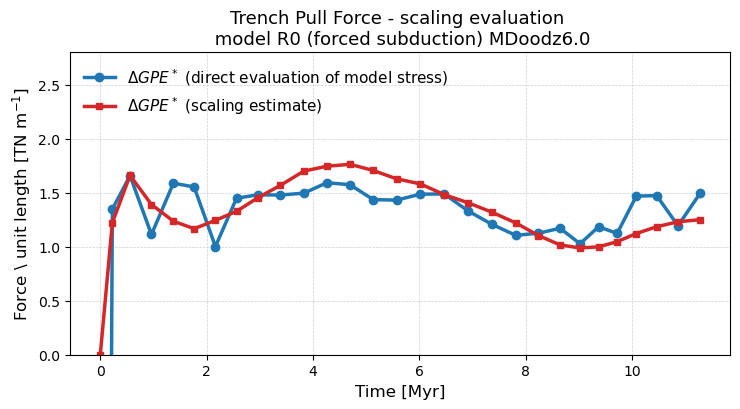

In [144]:
# ΔGPE*(xᵢ) vs time — direct model vs scaling estimate
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Direct model result — deep blue
ax.plot(
    dfR0["time_Myr"], dfR0["delta_gpe"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$\Delta GPE^*$ (direct evaluation of model stress)'
)

# Scaling estimate — strong orange
ax.plot(
    dfR0["time_Myr"], dfR0["trench_gpe_est"],
    marker='s', color='#d62728', lw=2.5, ms=5,
    label=r'$\Delta GPE^*$ (scaling estimate)'
)

# Labels and title
ax.set_xlabel("Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("Trench Pull Force - scaling evaluation \n model R0 (forced subduction) MDoodz6.0", fontsize=13)

# Aesthetics
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

**Comments**

The plot above compares the **direct estimate** of the $\Delta \mathrm{GPE}^*$ with a **scaling relationship** proposed in the the manuscript.

The proposed scaling of the $\Delta \mathrm{GPE}^*$  (trench pull force) is:

\begin{equation}
\text{trench pull force} \equiv \Delta \mathrm{GPE}^* = (\rho_m - \rho_w) g w_T ( \frac{z'_m}{2}) \approx \Delta P_T z_{np}
\end{equation}

where $w_T$ is the relative trench depth, and  $(\rho_m - \rho_w) g w_T$ is referred to the tranch pressure deficit, and $z'_{np}$ is the neutral plane depth

The direct estimate used the vertical normal stress from the numerical mdoel, and compares the difference in resulatant values at an isostatic column, vs the column beneath the trench axis, i.e.: 

\begin{equation}
\Delta \mathrm{GPE}^* = \bar \sigma_{zz}(x_I) - \bar \sigma_{zz}(x_T) 
\end{equation}


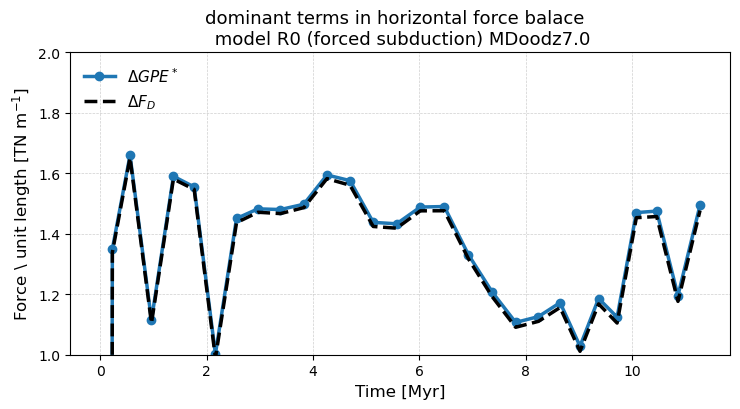

In [145]:
# ΔGPE*(xᵢ) vs time — direct model vs scaling estimate
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Direct model result — deep blue
ax.plot(
    dfR0["time_Myr"], dfR0["delta_gpe"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$\Delta GPE^*$'
)

# Scaling estimate — strong orange
ax.plot(
    dfR0["time_Myr"], dfR0["delta_Fd"], color='k', ls = '--', lw=2.5,
    label=r'$\Delta F_D$'
)

# Labels and title
ax.set_xlabel("Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("dominant terms in horizontal force balace  \n model R0 (forced subduction) MDoodz7.0", fontsize=13)

# Aesthetics
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(1, 2.)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

**Comments**

The vertically integrated horizontal force balance can be written as:

\begin{equation}
\Delta F_{D}  -  \Delta \mathrm{GPE}^*  +  F_B = 0 \;\; \mathrm{{\bf(3)}}
\end{equation}


The trench pull force is "developed" over the horizontal lenth scale of the trench topography (order 100 km). If we assumed 1 MPa as a charactersitc shear stress for the asthenosphere we have an integrated basal traction of $F_B$ of 0.1 TN/m. The implication is that $F_B$ is negligible on the spatial scale of the trench toporagpy. 

This means that any change given by the $\Delta \mathrm{GPE}^*$ must be almost exactly balanced by a equal change in $\Delta F_{D}$. By construction thes forces act in opposite direction, due to the definition of $\mathrm{GPE}^* = -\bar\sigma_{zz}$

The lithosphere must become increasigngl "tensional" - $F_D$ becomes more positive - between the trench and the isostatic plate. These considerations constrain the change in $F_D$, not the absolute value. 

The next plot lools at is the value of $F_D$ in the column beneath the trench axis.

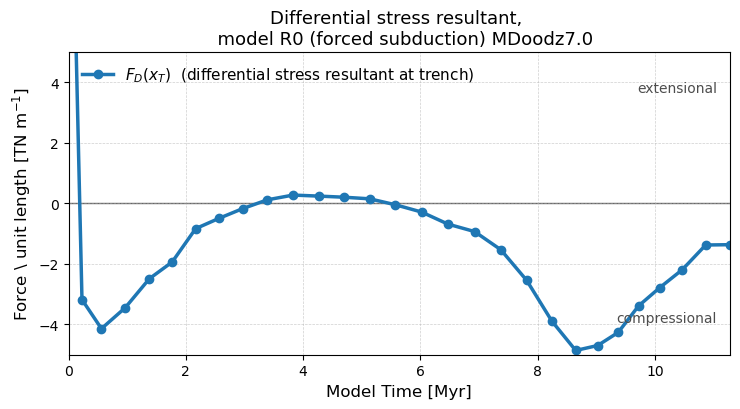

In [146]:
# Fᴰ(x_T) vs Time — Differential stress at the trench
fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.plot(
    dfR0["time_Myr"], dfR0["Fd_trench"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$F_D(x_T)$  (differential stress resultant at trench)'
)


# Axes and title
ax.set_xlabel("Model Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("Differential stress resultant, \n  model R0 (forced subduction) MDoodz7.0", fontsize=13)

# Zero reference line
ax.axhline(0, lw=1, color='k', alpha=0.6, zorder=0)

# Side labels (positive = extensional, negative = compressional)
ax.text(0.98, 0.88, "extensional", ha='right', va='center',
        transform=ax.transAxes, fontsize=10, color='0.3')
ax.text(0.98, 0.12, "compressional", ha='right', va='center',
        transform=ax.transAxes, fontsize=10, color='0.3')

# Aesthetics and limits
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(-5, 5)
ax.set_xlim(0, df0["time_Myr"].iloc[-1])
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

* Over most of the model evolution, the reference the value of $F_D$ at the trench varies between neutral and compressive, with typical values of the order of a few TN/m.  

## Plot results from Mdoodz6.0 models

A limited set of model outputs for both the forced (`S0`) and free (`S1`) reference models from the original publication—provided directly by one of the authors—has been compiled, analysed, and exported to CSV format for reference and comparison in the plots below.

In [147]:
dfS0 = pd.read_csv("outputs/MD6_S0.csv")
dfS1 = pd.read_csv("outputs/MD6_S1.csv")

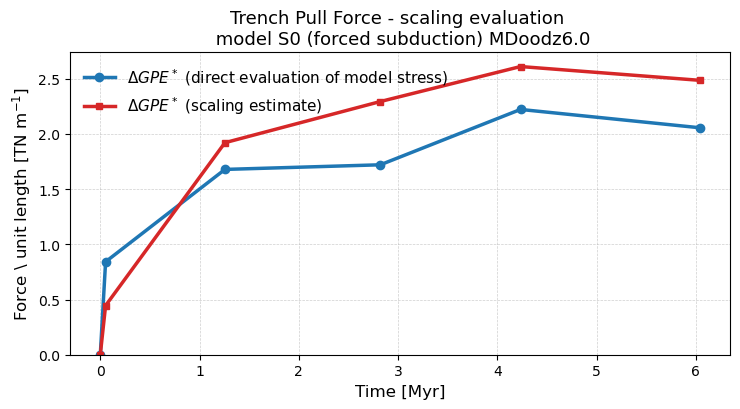

In [148]:
# ΔGPE*(xᵢ) vs time — direct model vs scaling estimate
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Direct model result — deep blue
ax.plot(
    dfS0["time_Myr"], dfS0["delta_gpe"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$\Delta GPE^*$ (direct evaluation of model stress)'
)

# Scaling estimate — strong orange
ax.plot(
    dfS0["time_Myr"], dfS0["trench_gpe_est"],
    marker='s', color='#d62728', lw=2.5, ms=5,
    label=r'$\Delta GPE^*$ (scaling estimate)'
)

# Labels and title
ax.set_xlabel("Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("Trench Pull Force - scaling evaluation \n model S0 (forced subduction) MDoodz6.0", fontsize=13)

# Aesthetics
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

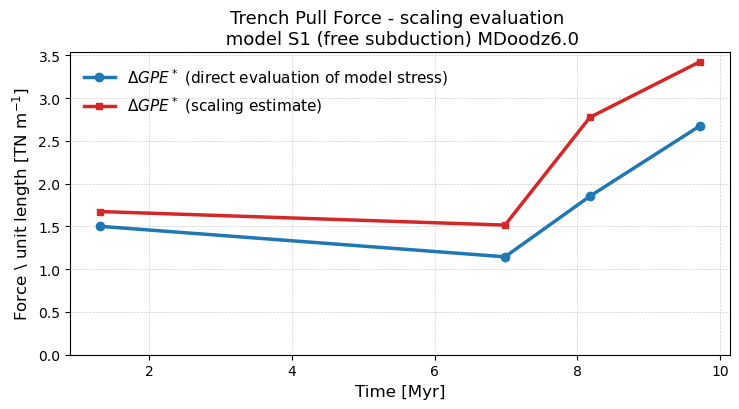

In [149]:
# ΔGPE*(xᵢ) vs time — direct model vs scaling estimate
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Direct model result — deep blue
ax.plot(
    dfS1["time_Myr"], dfS1["delta_gpe"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$\Delta GPE^*$ (direct evaluation of model stress)'
)

# Scaling estimate — strong orange
ax.plot(
    dfS1["time_Myr"], dfS1["trench_gpe_est"],
    marker='s', color='#d62728', lw=2.5, ms=5,
    label=r'$\Delta GPE^*$ (scaling estimate)'
)

# Labels and title
ax.set_xlabel("Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("Trench Pull Force - scaling evaluation \n model S1 (free subduction) MDoodz6.0", fontsize=13)

# Aesthetics
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

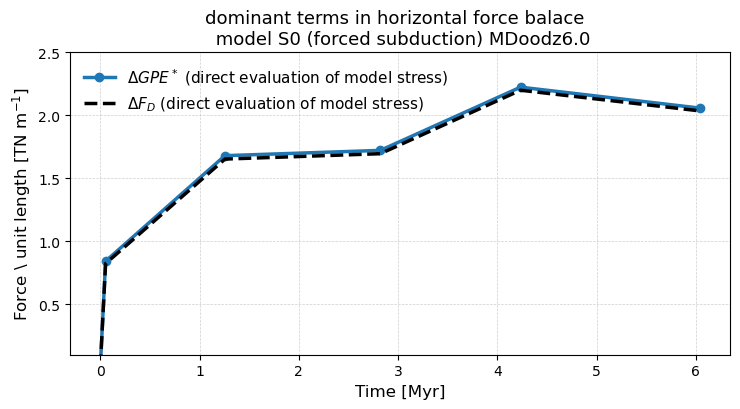

In [150]:
# ΔGPE*(xᵢ) vs time — direct model vs scaling estimate
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Direct model result — deep blue
ax.plot(
    dfS0["time_Myr"], dfS0["delta_gpe"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$\Delta GPE^*$ (direct evaluation of model stress)'
)

# Scaling estimate — strong orange
ax.plot(
    dfS0["time_Myr"], dfS0["delta_Fd"], color='k', ls = '--', lw=2.5,
    label=r'$\Delta F_D$ (direct evaluation of model stress)'
)

# Labels and title
ax.set_xlabel("Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("dominant terms in horizontal force balace  \n model S0 (forced subduction) MDoodz6.0", fontsize=13)

# Aesthetics
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(0.1, 2.5)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

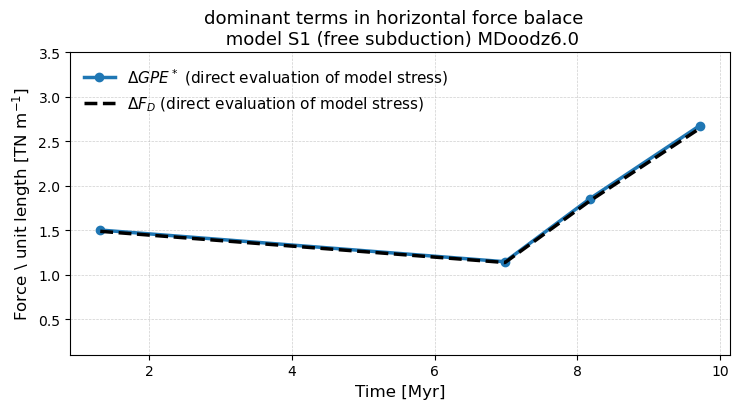

In [151]:
# ΔGPE*(xᵢ) vs time — direct model vs scaling estimate
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Direct model result — deep blue
ax.plot(
    dfS1["time_Myr"], dfS1["delta_gpe"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$\Delta GPE^*$ (direct evaluation of model stress)'
)

# Scaling estimate — strong orange
ax.plot(
    dfS1["time_Myr"], dfS1["delta_Fd"], color='k', ls = '--', lw=2.5,
    label=r'$\Delta F_D$ (direct evaluation of model stress)'
)

# Labels and title
ax.set_xlabel("Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("dominant terms in horizontal force balace  \n model S1 (free subduction) MDoodz6.0", fontsize=13)

# Aesthetics
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(0.1, 3.5)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

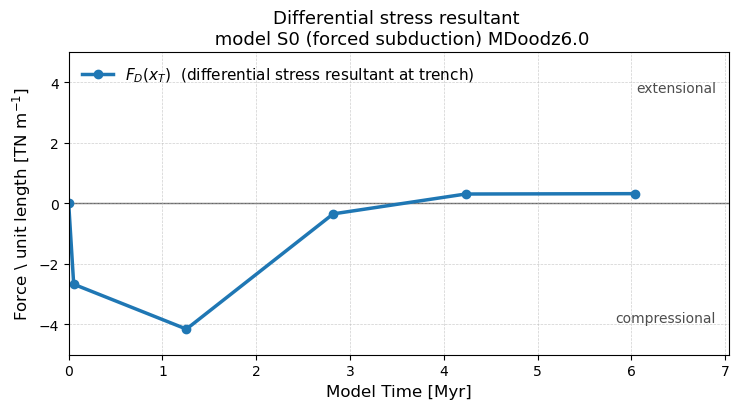

In [152]:
# Fᴰ(x_T) vs Time — Differential stress at the trench
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Plot trench differential stress over time
ax.plot(
    dfS0["time_Myr"], dfS0["Fd_trench"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$F_D(x_T)$  (differential stress resultant at trench)'
)


# Axes and title
ax.set_xlabel("Model Time [Myr]", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("Differential stress resultant \n model S0 (forced subduction) MDoodz6.0", fontsize=13)

# Zero reference line
ax.axhline(0, lw=1, color='k', alpha=0.6, zorder=0)

# Side labels (positive = extensional, negative = compressional)
ax.text(0.98, 0.88, "extensional", ha='right', va='center',
        transform=ax.transAxes, fontsize=10, color='0.3')
ax.text(0.98, 0.12, "compressional", ha='right', va='center',
        transform=ax.transAxes, fontsize=10, color='0.3')

# Aesthetics and limits
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(-5, 5)
ax.set_xlim(0, df1["time_Myr"].iloc[-1] + 1)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

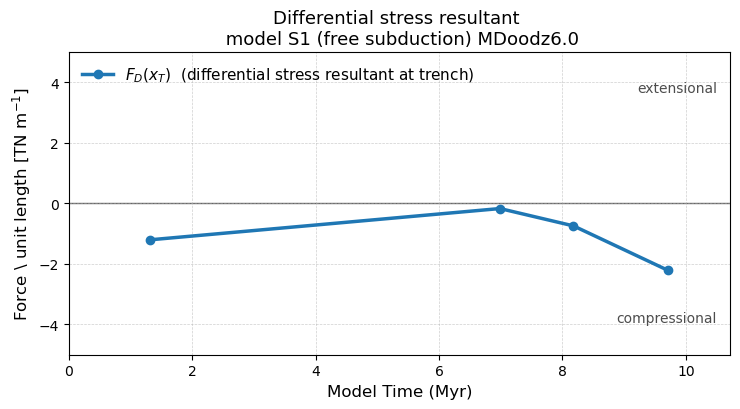

In [153]:
#Fᴰ(x_T) vs Time — Differential stress at the trench
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# Plot trench differential stress over time
ax.plot(
    dfS1["time_Myr"], dfS1["Fd_trench"],
    marker='o', color='#1f77b4', lw=2.5, ms=6,
    label=r'$F_D(x_T)$  (differential stress resultant at trench)'
)

# Axes and title
ax.set_xlabel("Model Time (Myr)", fontsize=12)
ax.set_ylabel(r"Force \ unit length [TN m$^{-1}$]", fontsize=12)
ax.set_title("Differential stress resultant \n model S1 (free subduction) MDoodz6.0", fontsize=13)

# Zero reference line
ax.axhline(0, lw=1, color='k', alpha=0.6, zorder=0)

# Side labels (positive = extensional, negative = compressional)
ax.text(0.98, 0.88, "extensional", ha='right', va='center',
        transform=ax.transAxes, fontsize=10, color='0.3')
ax.text(0.98, 0.12, "compressional", ha='right', va='center',
        transform=ax.transAxes, fontsize=10, color='0.3')

# Aesthetics and limits
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(-5, 5)
ax.set_xlim(0, df2["time_Myr"].iloc[-1] + 1)
ax.legend(frameon=False, fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()